In [2]:
import pandas as pd
import numpy as np
from tools import sherlock, box, histo, heatmap_corr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px

In [3]:
df = pd.read_csv(r"..\data\processed\final.csv", sep=';')

# ACP

### Étape 0 : Centrer-réduire 
-> Standardisation

In [4]:
X = df.select_dtypes('number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_scaled

array([[ 1.31196875,  0.17714705, -0.38159421, ...,  0.64851965,
         0.20679328, -0.29049409],
       [ 0.27295076,  0.29365751, -0.46230603, ..., -0.74815602,
         0.60957299,  1.05964019],
       [-0.85563774, -1.29674353, -0.48492235, ..., -0.62748717,
        -0.66160692, -0.8523331 ],
       ...,
       [ 0.23712256, -0.42722701, -0.40087185, ...,  0.14114827,
        -0.66628624, -0.86956138],
       [ 2.67344059,  1.58632693,  2.27296274, ...,  2.80393503,
        -0.62964684, -0.85349369],
       [-1.24974801, -1.30299607, -0.67810894, ..., -0.99525472,
        -0.66537612, -0.6991244 ]], shape=(131, 11))

-> Viz

In [6]:
# Array -> DF pour la viz
X_scaled = pd.DataFrame(X_scaled, index=df.index, columns=X.columns)
df_scalled = X_scaled.melt()

box(df_scalled, x="variable", y="value").show()

### Étape 1 : Lancer l'ACP

In [7]:
pca = PCA()
pca.fit(X_scaled)

# Variance expliquée par chaque composante
explained = pca.explained_variance_ratio_
print(explained.cumsum())  # cumul → quand dépasse 80% ?

[0.42792744 0.60173754 0.69582447 0.78003048 0.84953206 0.89490921
 0.92987171 0.95350491 0.97580971 0.99339737 1.        ]


### Étape 2 : L'éboulis des valeurs propres

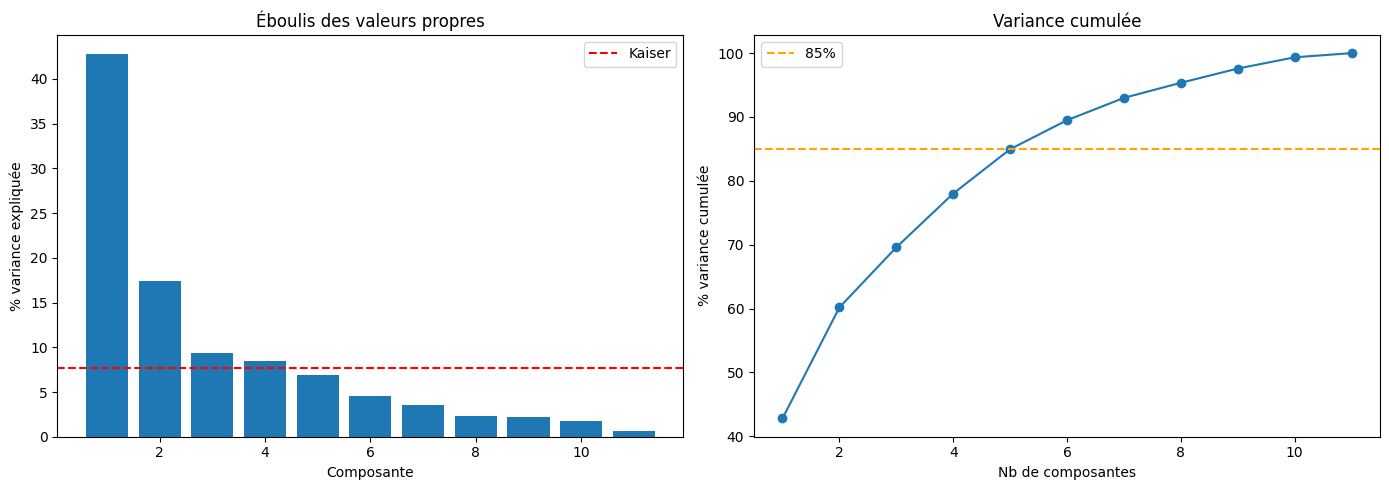

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Variance par composante
ax1.bar(range(1, len(explained)+1), explained * 100)
ax1.set_xlabel('Composante')
ax1.set_ylabel('% variance expliquée')
ax1.set_title('Éboulis des valeurs propres')
ax1.axhline(y=100/len(df.columns), color='red', linestyle='--', label='Kaiser')
ax1.legend()

# Variance cumulée
ax2.plot(range(1, len(explained)+1), explained.cumsum() * 100, marker='o')
ax2.axhline(y=85, color='orange', linestyle='--', label='85%')
ax2.set_xlabel('Nb de composantes')
ax2.set_ylabel('% variance cumulée')
ax2.set_title('Variance cumulée')
ax2.legend()

plt.tight_layout()
plt.show()

### Étape 3 : Le cercle des corrélations

F1 & F2

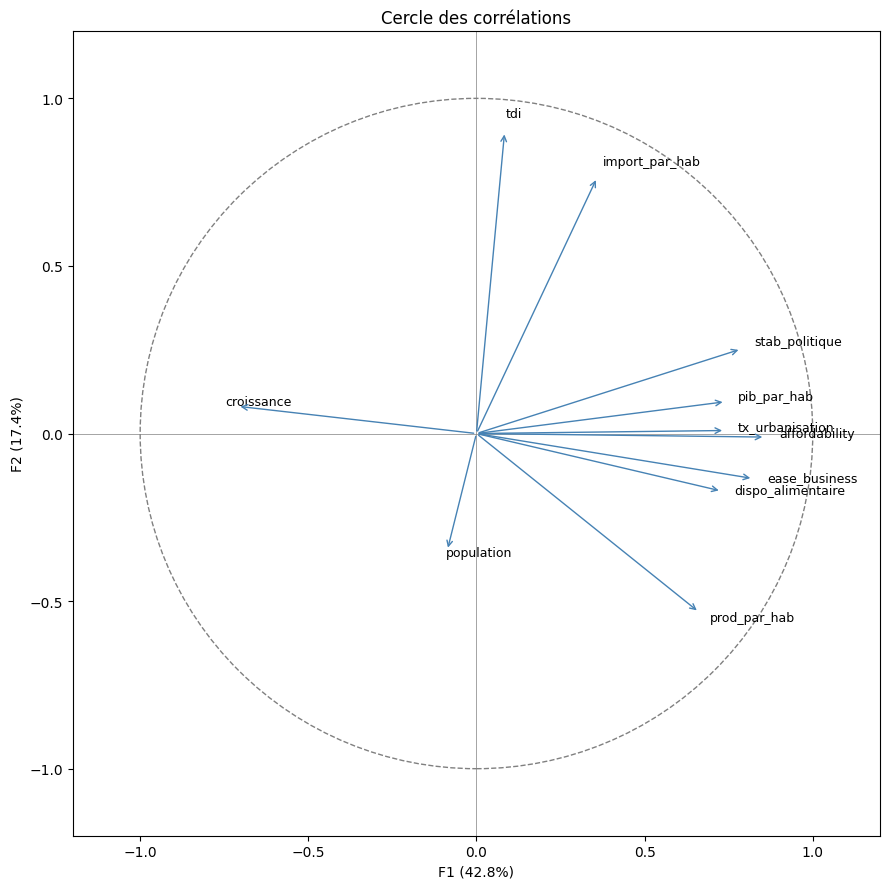

In [9]:
def cercle_correlations(pca, features, axes=(0, 1)):
    """Affiche le cercle des corrélations pour 2 axes donnés"""
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Corrélations variables / composantes
    correlations = pca.components_[list(axes)].T * np.sqrt(pca.explained_variance_[list(axes)])
    
    for i, feat in enumerate(features):
        ax.annotate(feat, xy=(correlations[i, 0], correlations[i, 1]),
                    xytext=(correlations[i, 0]*1.05, correlations[i, 1]*1.05),
                    fontsize=9)
        ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color='steelblue'))
    
    circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
    ax.add_patch(circle)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(f'F{axes[0]+1} ({pca.explained_variance_ratio_[axes[0]]:.1%})')
    ax.set_ylabel(f'F{axes[1]+1} ({pca.explained_variance_ratio_[axes[1]]:.1%})')
    ax.set_title('Cercle des corrélations')
    plt.tight_layout()
    plt.show()

pca_final = PCA(n_components=5)  # à ajuster après l'éboulis
pca_final.fit(X_scaled)
cercle_correlations(pca_final, X.columns, axes=(0, 1))

F3 & F4

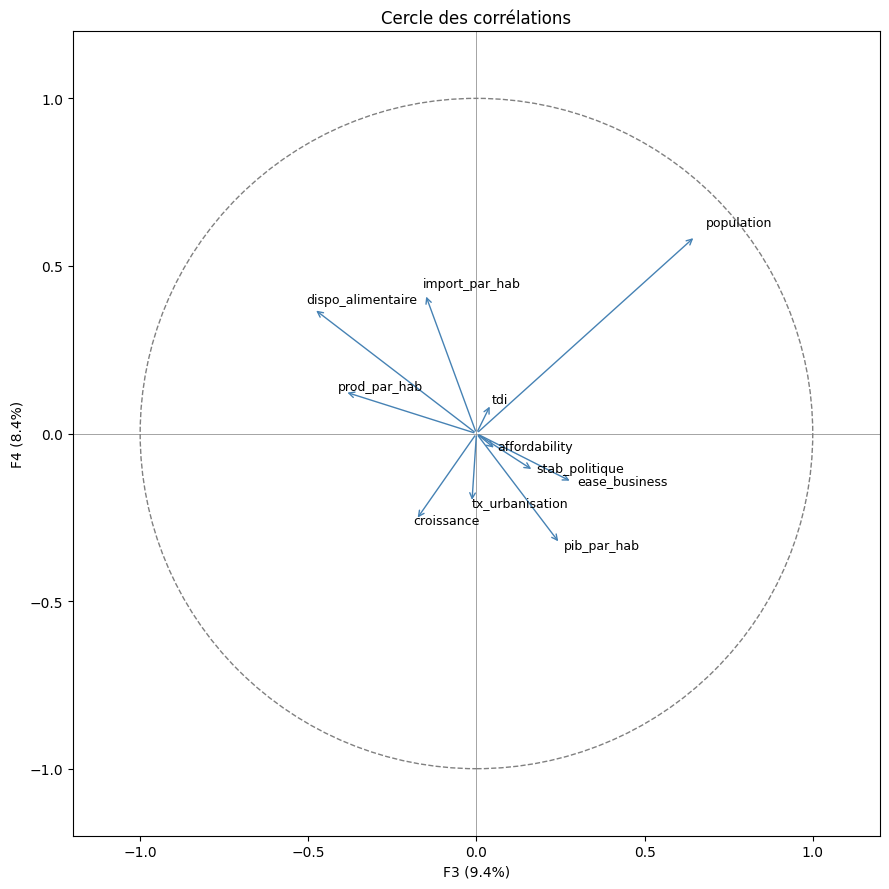

In [10]:
pca_final = PCA(n_components=5)  # à ajuster après l'éboulis
pca_final.fit(X_scaled)
cercle_correlations(pca_final, X.columns, axes=(2, 3))

F1 vs F3

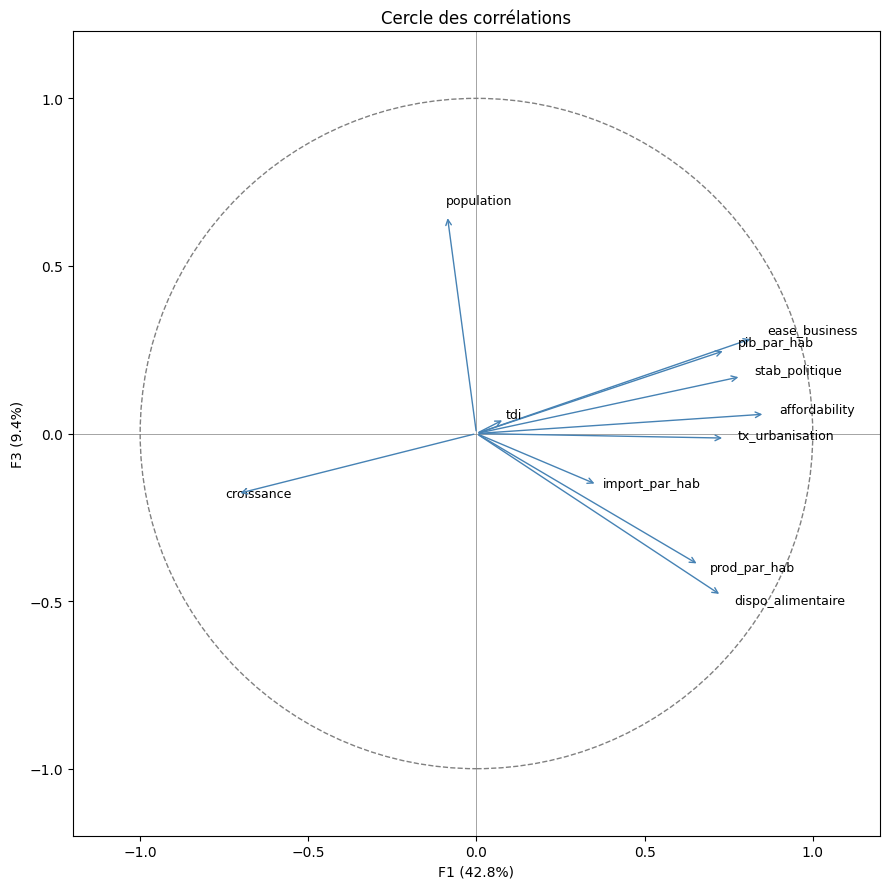

In [11]:
pca_final = PCA(n_components=5)  # à ajuster après l'éboulis
pca_final.fit(X_scaled)
cercle_correlations(pca_final, X.columns, axes=(0, 2))

## 🔍 Interprétation des axes ACP

### F1 (42.7%) — Niveau de développement
Variables → droite : `pib_par_hab`, `tx_urbanisation`, `affordability`, 
`ease_business`, `dispo_alimentaire`, `stab_politique`
Variable → gauche : `croissance`
**Lecture** : F1 oppose les pays développés (droite) aux pays en développement 
à forte croissance démographique (gauche)

### F2 (17.7%) — Dépendance commerciale
Variables → haut : `tdi`, `import_par_hab`
Variables → bas : `population`, `prod_par_hab`
**Lecture** : F2 oppose les pays dépendants des imports (haut) aux pays 
autonomes et producteurs (bas)

### Étape 4 : Plan factoriel des individus (les pays sur F1/F2)

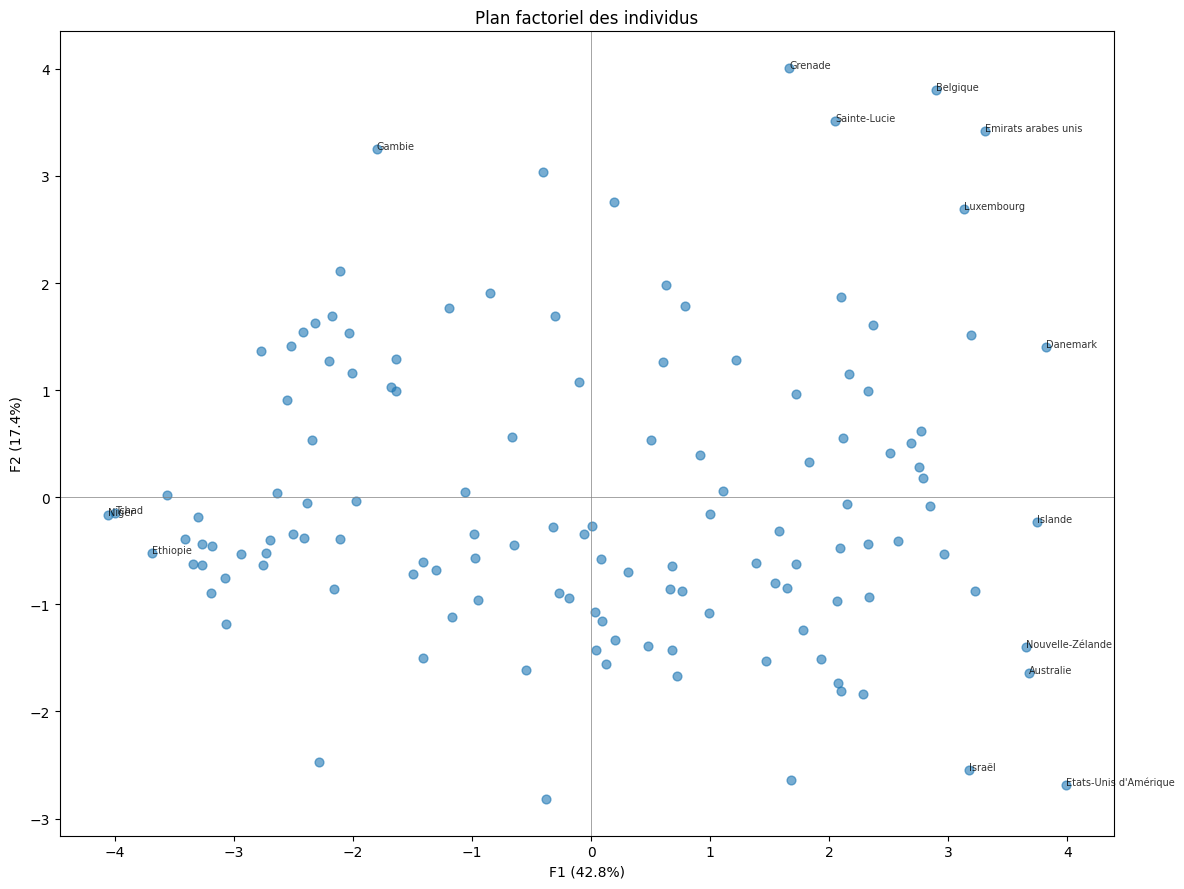

In [12]:
def plan_factoriel(pca, X_scaled, labels, axes=(0, 1), n_labels=15):
    """Projette les individus sur le plan F_i / F_j"""
    coords = pca.transform(X_scaled)
    
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.scatter(coords[:, axes[0]], coords[:, axes[1]], alpha=0.6, s=40)
    
    # Annoter les n pays les plus "extrêmes" (intéressants à lire)
    distances = np.sqrt(coords[:, axes[0]]**2 + coords[:, axes[1]]**2)
    top_idx = np.argsort(distances)[-n_labels:]
    
    for i in top_idx:
        ax.annotate(labels[i], (coords[i, axes[0]], coords[i, axes[1]]),
                    fontsize=7, alpha=0.8)
    
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(f'F{axes[0]+1} ({pca.explained_variance_ratio_[axes[0]]:.1%})')
    ax.set_ylabel(f'F{axes[1]+1} ({pca.explained_variance_ratio_[axes[1]]:.1%})')
    ax.set_title('Plan factoriel des individus')
    plt.tight_layout()
    plt.show()

plan_factoriel(pca_final, X_scaled, df.pays.tolist())

# Clustering

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Trouver le bon K avec la méthode du coude

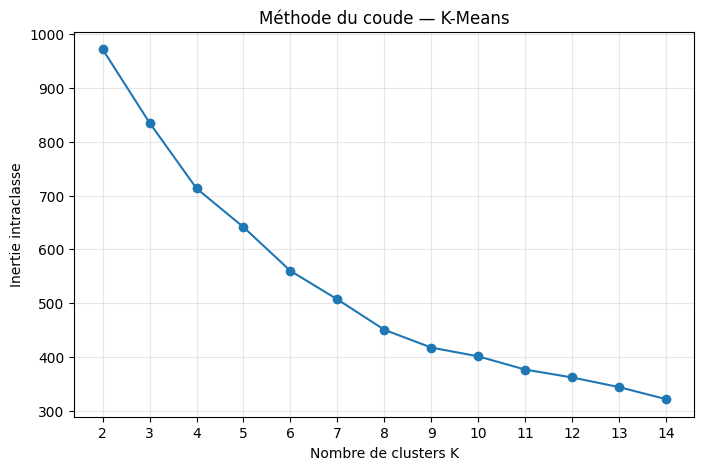

In [14]:
inertias = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie intraclasse')
plt.title('Méthode du coude — K-Means')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

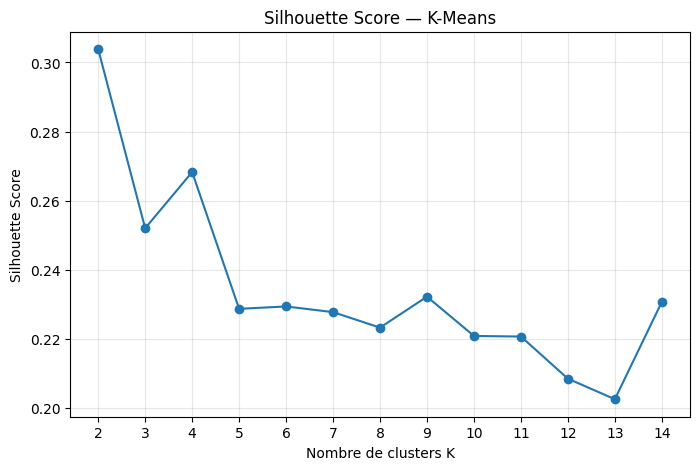

In [15]:
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — K-Means')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

CAH (Classification Ascendante Hiérarchique)

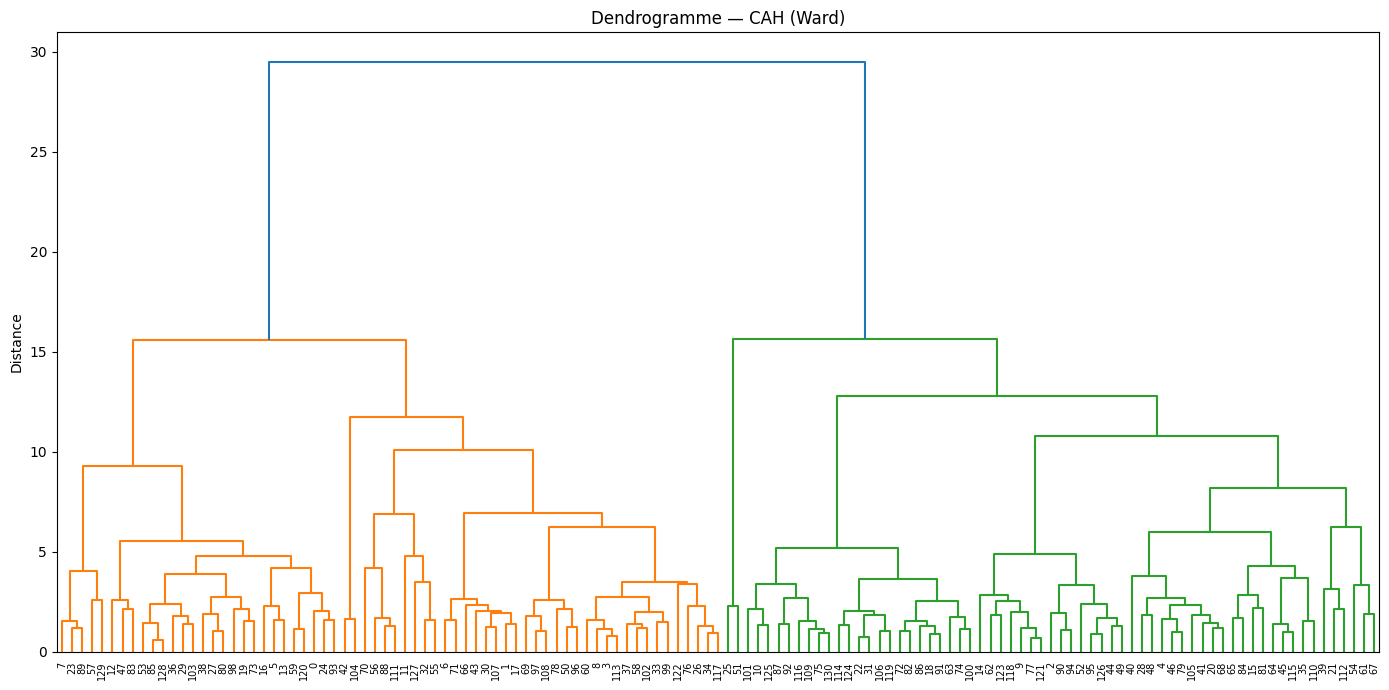

In [16]:
# Calcul des distances (méthode de Ward par défaut)
Z = linkage(X_scaled, method='ward')

# Dendrogramme (tronqué pour lisibilité)
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, labels=df.index.tolist(), leaf_rotation=90,
           leaf_font_size=7, truncate_mode=None, ax=ax)
ax.set_title('Dendrogramme — CAH (Ward)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

### Clustering

Kmean

In [17]:
k_optimal = 4  # à déterminer avec le coude
km_final = KMeans(n_clusters=k_optimal, n_init=20, random_state=42)
km_final.fit(X_scaled)
labels_km = km_final.labels_
df_kmean = df.copy()
df_kmean['cluster'] = labels_km
df_kmean.head()

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi,cluster
0,Afrique du Sud,143.0,65.32778,6618.335083,-0.382832,57009.756,6.188887,63.331108,39.2,ZAF,29.240609,9.016001,24.268178,1
1,Albanie,85.0,66.83770,5006.360130,0.163830,2884.169,-0.675703,55.980276,75.7,ALB,4.507364,13.175372,80.851064,2
2,Algérie,22.0,46.22686,4554.667540,-0.929505,41389.189,8.518733,71.322791,81.2,DZA,6.644247,0.048322,0.722022,0
3,Allemagne,71.0,79.34962,45553.934150,0.702224,82658.409,1.828215,80.984254,97.3,DEU,18.316346,10.186501,48.418631,2
4,Angola,35.0,39.00774,2790.718869,-0.537214,29816.766,14.610305,65.085053,39.3,AGO,1.408603,9.290075,86.833856,0


In [18]:
df_kmean['cluster'].value_counts().sort_index()

cluster
0    53
1    39
2    37
3     2
Name: count, dtype: int64

In [19]:
df_num = df_kmean.select_dtypes('number')
profile_k = df_num.groupby('cluster').mean().round(2)
print(profile_k)

         dispo_alimentaire  ease_business  pib_par_hab  stab_politique  \
cluster                                                                  
0                    23.92          52.20      2090.60           -0.74   
1                   121.69          68.49     14938.04            0.04   
2                    82.68          72.83     31380.08            0.68   
3                    33.00          62.55      5464.89           -0.39   

         population  croissance  tx_urbanisation  affordability  prod_par_hab  \
cluster                                                                         
0          37489.47        9.37            43.55          42.69          4.53   
1          40115.88        3.70            68.90          79.31         38.27   
2          13028.43        2.11            72.14          86.88         15.62   
3        1379849.29        3.30            46.71          55.80          7.74   

         import_par_hab    tdi  
cluster                         
0 

CAH

In [20]:
k_cah = 4  # tu coupes l'arbre où ça fait sens visuellement
labels_cah = fcluster(Z, t=k_cah, criterion='maxclust') - 1  # pour commencer à 0

In [21]:
df_cah = df.copy()
df_cah['cluster'] = labels_cah
df_cah.head()

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi,cluster
0,Afrique du Sud,143.0,65.32778,6618.335083,-0.382832,57009.756,6.188887,63.331108,39.2,ZAF,29.240609,9.016001,24.268178,0
1,Albanie,85.0,66.83770,5006.360130,0.163830,2884.169,-0.675703,55.980276,75.7,ALB,4.507364,13.175372,80.851064,1
2,Algérie,22.0,46.22686,4554.667540,-0.929505,41389.189,8.518733,71.322791,81.2,DZA,6.644247,0.048322,0.722022,3
3,Allemagne,71.0,79.34962,45553.934150,0.702224,82658.409,1.828215,80.984254,97.3,DEU,18.316346,10.186501,48.418631,1
4,Angola,35.0,39.00774,2790.718869,-0.537214,29816.766,14.610305,65.085053,39.3,AGO,1.408603,9.290075,86.833856,3


In [22]:
df_cah['cluster'].value_counts().sort_index()

cluster
0    28
1    38
2     2
3    63
Name: count, dtype: int64

In [23]:
df_num = df_cah.select_dtypes('number')
profile_cah = df_num.groupby('cluster').mean().round(2)
print(profile_cah)

         dispo_alimentaire  ease_business  pib_par_hab  stab_politique  \
cluster                                                                  
0                   138.29          66.14     15523.78           -0.01   
1                    87.74          75.29     32997.73            0.74   
2                    33.00          62.55      5464.89           -0.39   
3                    29.63          54.27      2632.84           -0.64   

         population  croissance  tx_urbanisation  affordability  prod_par_hab  \
cluster                                                                         
0          46862.06        4.43            70.08          75.52         41.76   
1          16427.43        1.02            71.04          87.61         20.71   
2        1379849.29        3.30            46.71          55.80          7.74   
3          33287.83        8.83            47.66          49.62          5.63   

         import_par_hab    tdi  
cluster                         
0 

Viz

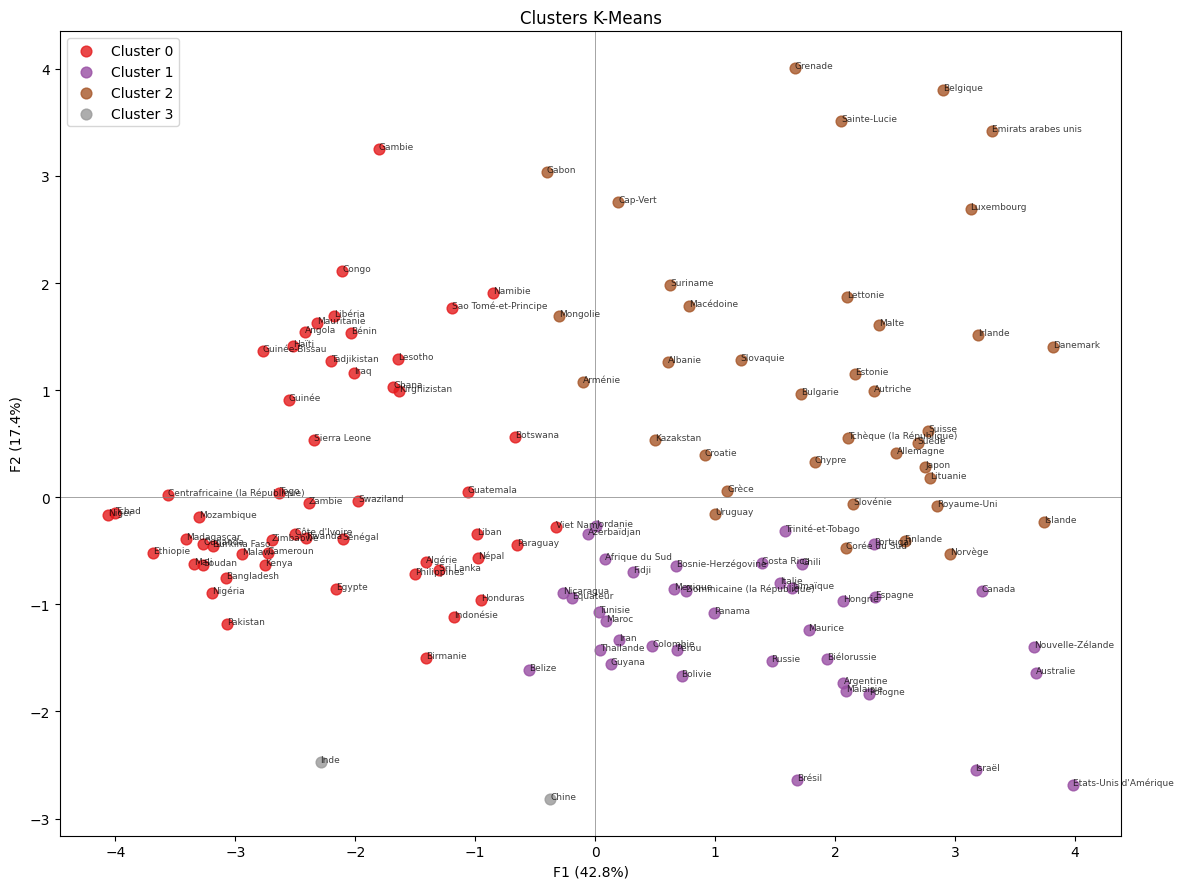

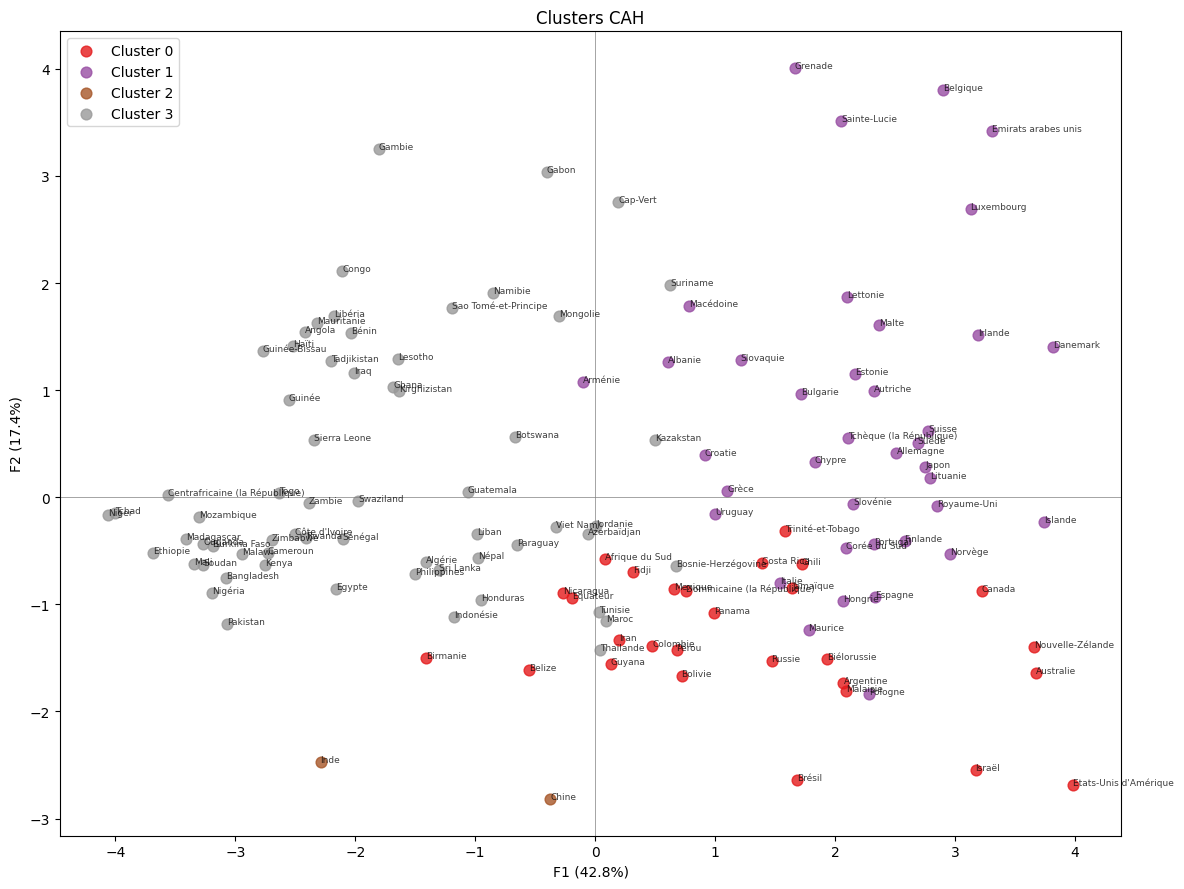

In [24]:
def plot_clusters_pca(pca, X_scaled, labels, pays, titre='Clusters sur plan factoriel', axes=(0, 1)):
    coords = pca.transform(X_scaled)
    n_clusters = len(set(labels))
    colors = cm.Set1(np.linspace(0, 1, n_clusters))
    
    fig, ax = plt.subplots(figsize=(12, 9))
    for c in range(n_clusters):
        mask = labels == c
        ax.scatter(coords[mask, axes[0]], coords[mask, axes[1]],
                   label=f'Cluster {c}', s=60, alpha=0.8, color=colors[c])
        for i, p in enumerate(pays):
            if mask[i]:
                ax.annotate(p, (coords[i, axes[0]], coords[i, axes[1]]),
                            fontsize=6.5, alpha=0.75)
    
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.legend()
    ax.set_title(titre)
    ax.set_xlabel(f'F{axes[0]+1} ({pca.explained_variance_ratio_[axes[0]]:.1%})')
    ax.set_ylabel(f'F{axes[1]+1} ({pca.explained_variance_ratio_[axes[1]]:.1%})')
    plt.tight_layout()
    plt.show()

plot_clusters_pca(pca_final, X_scaled, labels_km, df.pays.tolist(), 'Clusters K-Means')
plot_clusters_pca(pca_final, X_scaled, labels_cah, df.pays.tolist(), 'Clusters CAH')

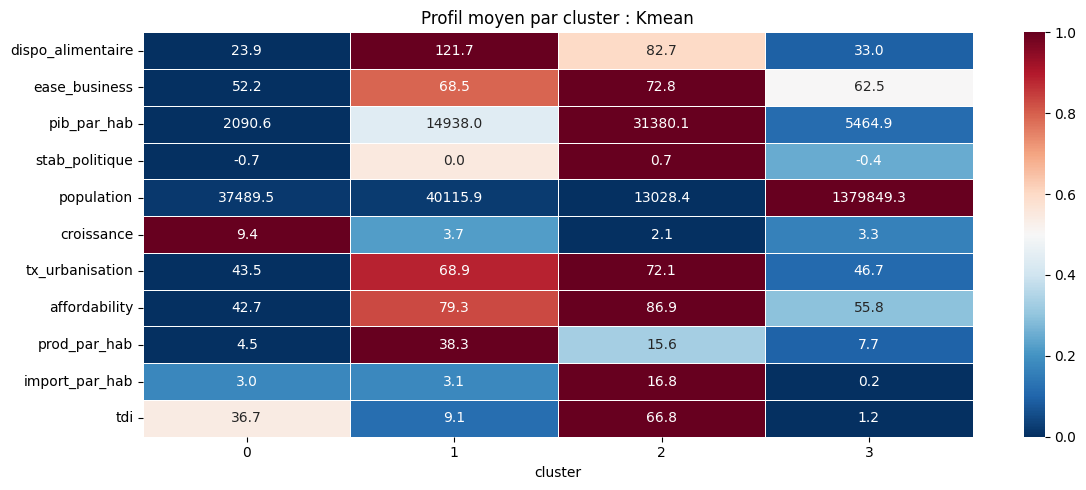

In [25]:
profile_norm = (profile_k - profile_k.min()) / (profile_k.max() - profile_k.min())  # normalisation 0-1 pour la heatmap

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_norm.T, annot=profile_k.T, fmt='.1f',
            cmap='RdBu_r', ax=ax, linewidths=0.5)
ax.set_title('Profil moyen par cluster : Kmean')
plt.tight_layout()
plt.show()

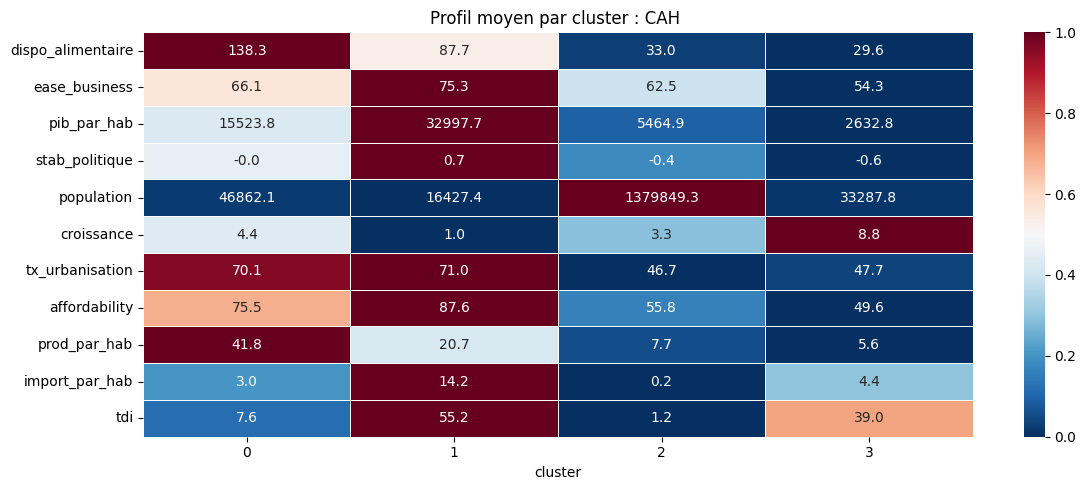

In [26]:
profile_norm = (profile_cah - profile_cah.min()) / (profile_cah.max() - profile_cah.min())  # normalisation 0-1 pour la heatmap

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_norm.T, annot=profile_cah.T, fmt='.1f',
            cmap='RdBu_r', ax=ax, linewidths=0.5)
ax.set_title('Profil moyen par cluster : CAH ')
plt.tight_layout()
plt.show()

# Analyse du Cluster Principal

In [27]:
from sklearn.preprocessing import MinMaxScaler
cluster2 = df_kmean[df_kmean['cluster'] == 2].copy()

In [28]:
# Regarder la dispersion DANS le cluster
cluster2.describe().round(1)

,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,prod_par_hab,import_par_hab,tdi,cluster
count,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0
mean,82.7,72.8,31380.1,0.7,13028.4,2.1,72.1,86.9,15.6,16.8,66.9,2.0
std,42.4,10.1,26263.1,0.5,26442.4,3.5,16.3,12.5,10.8,14.3,40.2,0.0
min,9.0,44.7,3646.0,-0.5,110.9,-5.4,21.8,50.6,0.0,0.4,2.0,2.0
25%,61.0,67.4,9751.4,0.4,1951.1,0.5,64.7,76.1,9.0,8.4,44.3,2.0
50%,71.0,76.4,20913.2,0.8,4182.9,1.9,72.0,91.4,15.3,11.9,64.3,2.0
75%,99.0,80.0,45553.9,0.9,9487.2,3.1,84.7,97.3,21.2,20.8,87.5,2.0
max,241.0,84.6,110193.2,1.3,127502.7,13.6,95.2,99.4,41.5,63.1,222.4,2.0


In [29]:
# Normaliser les variables du score entre 0 et 1
vars_score = ['affordability', 'ease_business', 'import_par_hab', 'population']
scaler_score = MinMaxScaler()
cluster2_norm = cluster2.copy()
cluster2_norm[vars_score] = scaler_score.fit_transform(cluster2[vars_score])

# Score avec poids
cluster2_norm['score'] = (
    cluster2_norm['affordability'] * 0.3 +
    cluster2_norm['ease_business'] * 0.2 +
    cluster2_norm['import_par_hab'] * 0.25 +
    cluster2_norm['population'] * 0.25
)

cluster2_norm.sort_values('score', ascending=False)[
    ['pays', 'score', 'affordability', 'ease_business', 'import_par_hab', 'population']
].head(15)

,pays,score,affordability,ease_business,import_par_hab,population
60,Japon,0.708400,0.864754,0.835394,0.127579,1.000000
3,Allemagne,0.661935,0.956967,0.868874,0.156299,0.647981
127,Emirats arabes unis,0.656254,0.946721,0.867639,0.721238,0.073602
99,Royaume-Uni,0.652905,0.946721,0.965777,0.180007,0.522927
32,Danemark,0.600111,0.993852,1.000000,0.363693,0.044127
11,Belgique,0.567211,0.969262,0.689188,0.465608,0.088772
104,Sainte-Lucie,0.564284,0.836066,0.473432,0.874563,0.000550
55,Irlande,0.557671,0.965164,0.887731,0.325861,0.036442
102,Corée du Sud,0.547132,0.803279,0.984575,0.036706,0.400226
8,Autriche,0.524142,0.961066,0.852763,0.192714,0.068364


In [32]:
carte = cluster2_norm.sort_values('score', ascending=False)[
    ['pays', 'score', 'affordability', 'ease_business', 'import_par_hab', 'population']
].head(15)
carte.to_csv(r"..\data\processed\carte.csv", index=False, sep=';', encoding='utf-8-sig')